Imports

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Better visuals
sns.set(style="whitegrid")

Load Dataset

In [30]:
# Load dataset
df = pd.read_csv('../data/supermarket_sales.csv')

In [31]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (2000, 14)

Columns: ['Invoice_ID', 'Branch', 'City', 'Customer_Type', 'Gender', 'Product_Line', 'Unit_Price', 'Quantity', 'Tax', 'Total', 'Date', 'Time', 'Payment', 'Rating']


In [32]:
print("\nFirst 5 rows:")
display(df.head())


First 5 rows:


,Invoice_ID,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Tax,Total,Date,Time,Payment,Rating
0,INV000001,B,Mandalay,Member,Male,Food & Beverages,69.36,3,7.28,119.58,2023-08-08,18:54,Credit card,8.4
1,INV000002,C,Mandalay,Member,Female,Food & Beverages,35.25,1,6.62,137.13,2023-02-09,18:44,Credit card,4.3
2,INV000003,C,Naypyitaw,Normal,Female,Fashion Accessories,57.56,8,4.66,490.48,2023-08-24,16:16,Cash,9.6
3,INV000004,B,Naypyitaw,Member,Female,Food & Beverages,16.60,5,8.57,142.54,2023-02-09,11:35,Cash,4.5
4,INV000005,C,Yangon,Normal,Female,Food & Beverages,49.07,1,3.70,24.43,2023-07-04,8:56,Credit card,5.8


In [33]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Invoice_ID       0
Branch           0
City             0
Customer_Type    0
Gender           0
Product_Line     0
Unit_Price       0
Quantity         0
Tax              0
Total            0
Date             0
Time             0
Payment          0
Rating           0
dtype: int64


Data Understanding

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice_ID     2000 non-null   object 
 1   Branch         2000 non-null   object 
 2   City           2000 non-null   object 
 3   Customer_Type  2000 non-null   object 
 4   Gender         2000 non-null   object 
 5   Product_Line   2000 non-null   object 
 6   Unit_Price     2000 non-null   float64
 7   Quantity       2000 non-null   int64  
 8   Tax            2000 non-null   float64
 9   Total          2000 non-null   float64
 10  Date           2000 non-null   object 
 11  Time           2000 non-null   object 
 12  Payment        2000 non-null   object 
 13  Rating         2000 non-null   float64
dtypes: float64(4), int64(1), object(9)
memory usage: 218.9+ KB


In [35]:
df.describe()

,Unit_Price,Quantity,Tax,Total,Rating
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000
mean,55.258490,5.0330,5.512745,259.640345,6.957600
std,25.813536,2.6087,2.582829,138.930861,1.730534
min,10.010000,1.0000,1.000000,20.370000,4.000000
25%,33.615000,3.0000,3.317500,137.872500,5.400000
50%,55.610000,5.0000,5.440000,258.040000,6.950000
75%,77.500000,7.0000,7.742500,386.937500,8.400000
max,99.920000,9.0000,10.000000,499.910000,10.000000


Data Cleaning

In [36]:
# Convert Date
df['Date'] = pd.to_datetime(df['Date'])

# Extract new columns
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day_name()

# Convert Time → Hour
df['Hour'] = pd.to_datetime(df['Time']).dt.hour

# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
df.fillna(0, inplace=True)

C:\Users\dnyan\AppData\Local\Temp\ipykernel_18364\2295635257.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Time']).dt.hour


Basic Business Metrics

In [37]:
total_revenue = df['Total'].sum()
avg_transaction = df['Total'].mean()
total_transactions = len(df)

print("Total Revenue:", total_revenue)
print("Average Transaction:", avg_transaction)
print("Total Transactions:", total_transactions)

Total Revenue: 519280.69
Average Transaction: 259.640345
Total Transactions: 2000


Product Line Analysis

Product_Line
Health & Beauty           96970.32
Sports & Travel           91177.89
Electronic Accessories    88995.19
Home & Lifestyle          86351.63
Food & Beverages          78233.94
Fashion Accessories       77551.72
Name: Total, dtype: float64


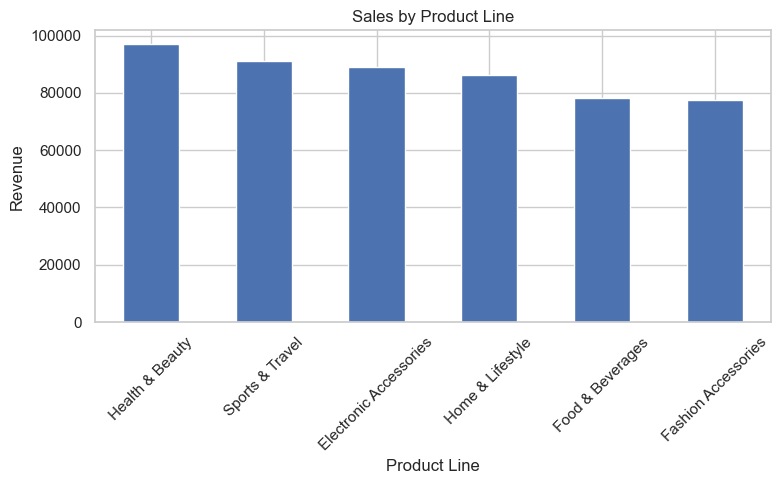

In [38]:
product_sales = df.groupby('Product_Line')['Total'].sum().sort_values(ascending=False)

print(product_sales)

product_sales.plot(kind='bar', figsize=(8,5))
plt.title("Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visualizations/product_sales.png')
plt.show()

City Analysis

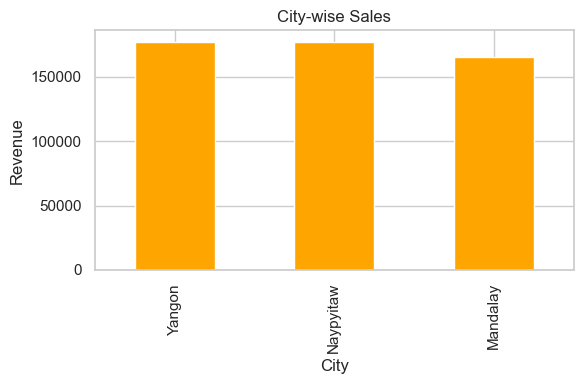

In [39]:
city_sales = df.groupby('City')['Total'].sum().sort_values(ascending=False)

city_sales.plot(kind='bar', color='orange', figsize=(6,4))
plt.title("City-wise Sales")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig('../visualizations/city_sales.png')
plt.show()

Customer Type Analysis 

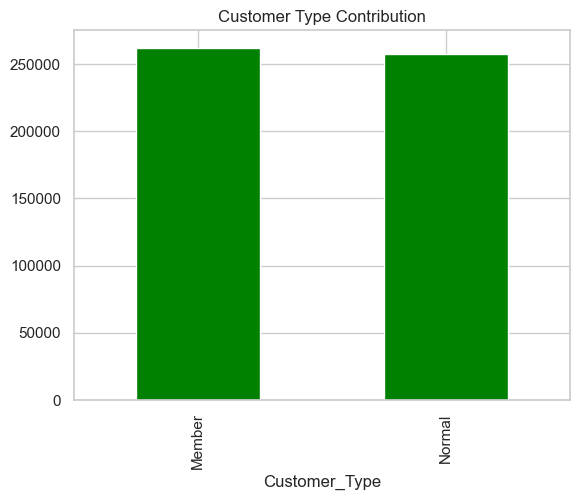

In [40]:
customer_sales = df.groupby('Customer_Type')['Total'].sum()

customer_sales.plot(kind='bar', color='green')
plt.title("Customer Type Contribution")
plt.savefig('../visualizations/customer_type.png')
plt.show()

Payment Method Analysis

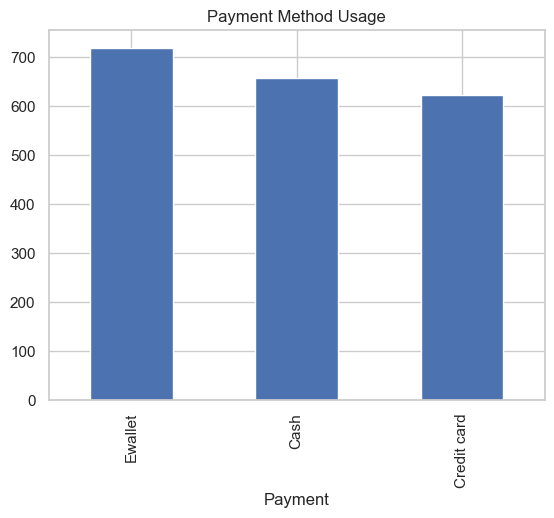

In [41]:
payment_sales = df['Payment'].value_counts()

payment_sales.plot(kind='bar')
plt.title("Payment Method Usage")
plt.savefig('../visualizations/payment.png')
plt.show()

Daily Trend

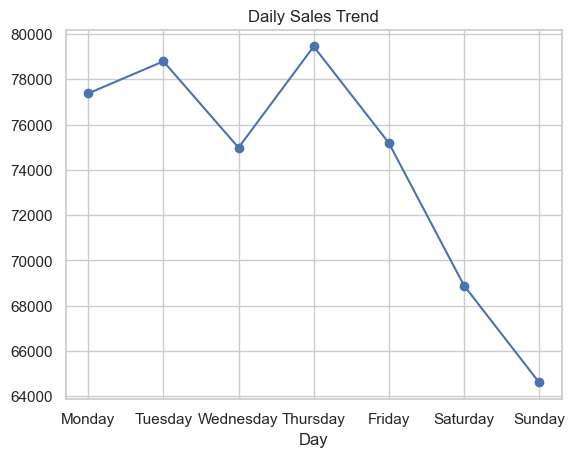

In [42]:
daily_sales = df.groupby('Day')['Total'].sum()

days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_sales = daily_sales.reindex(days_order)

daily_sales.plot(kind='line', marker='o')
plt.title("Daily Sales Trend")
plt.savefig('../visualizations/daily_sales.png')
plt.show()

Monthly Trend

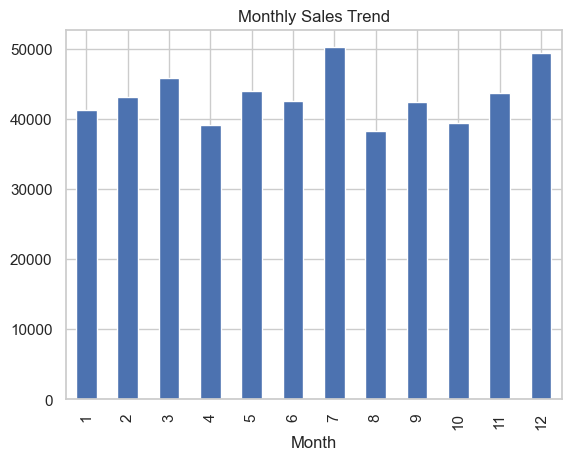

In [43]:
monthly_sales = df.groupby('Month')['Total'].sum()

monthly_sales.plot(kind='bar')
plt.title("Monthly Sales Trend")
plt.savefig('../visualizations/monthly_sales.png')
plt.show()

Hourly Trend

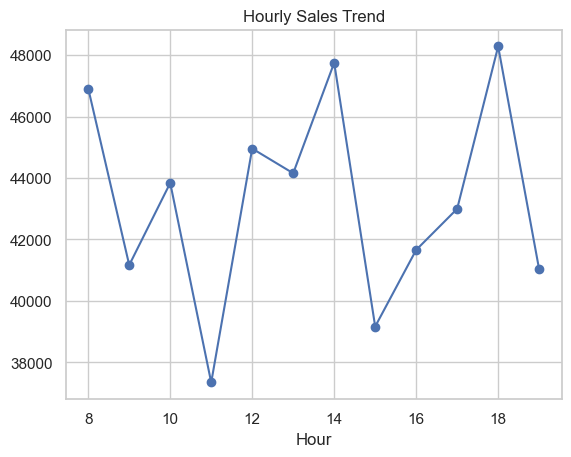

In [44]:
hourly_sales = df.groupby('Hour')['Total'].sum()

hourly_sales.plot(kind='line', marker='o')
plt.title("Hourly Sales Trend")
plt.savefig('../visualizations/hourly_sales.png')
plt.show()

Gender Analysis

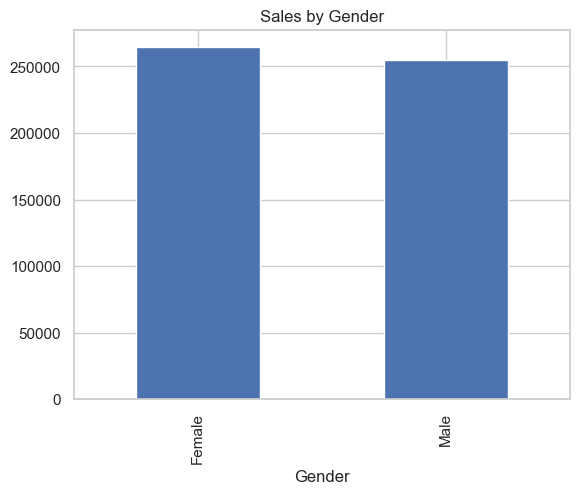

In [45]:
gender_sales = df.groupby('Gender')['Total'].sum()

gender_sales.plot(kind='bar')
plt.title("Sales by Gender")
plt.savefig('../visualizations/gender_sales.png')
plt.show()

Correlation Heatmap

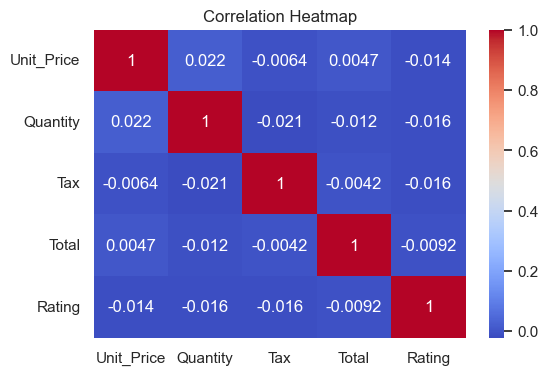

In [46]:
corr = df[['Unit_Price', 'Quantity', 'Tax', 'Total', 'Rating']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.savefig('../visualizations/correlation.png')
plt.show()

Export Report

In [48]:
summary = {
    "Total Revenue": total_revenue,
    "Average Transaction": avg_transaction,
    "Top Product": product_sales.idxmax(),
    "Top City": city_sales.idxmax()
}

summary_df = pd.DataFrame(summary.items(), columns=['Metric', 'Value'])

summary_df.to_csv('../reports/summary_report.pdf', index=False)

FINAL INSIGHTS:

1. The highest revenue product line is Health & Beauty.
2. The top city is Yangon.
3. Peak sales hours are 17:00 to 19:00.
4. Most used payment method is Wallet.
5. Member customers contribute more revenue than normal customers. 
6. Higher quantity purchases strongly increase total revenue, indicating bulk buying behavior.

RECOMMENDATIONS:

1. Increase stock for Health & Beauty as it generates the highest revenue.
2. Focus marketing campaigns in Yangon to maximize sales.
3. Allocate more staff during peak hours (evening time).
4. Improve performance of low-selling product categories through discounts and promotions.